In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 1. Open dataset and EDA

In [2]:
data = fetch_20newsgroups(remove=("headers", "footers", "quotes"))

In [3]:
# Separe features from target

X = data.data
y = data.target

In [4]:
target_names = data.target_names

In [5]:
print(X[0])

I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.


In [6]:
print(y[0])
print(target_names[y[0]])

7
rec.autos


In [7]:
# Dimensions of the dataset

print(f"Number of documents: {len(X)}")
print(f"Number of classes: {len(target_names)}")

Number of documents: 11314
Number of classes: 20


In [8]:
# Which ones are the classes

for i, category in enumerate(target_names):
    print(i, category)

0 alt.atheism
1 comp.graphics
2 comp.os.ms-windows.misc
3 comp.sys.ibm.pc.hardware
4 comp.sys.mac.hardware
5 comp.windows.x
6 misc.forsale
7 rec.autos
8 rec.motorcycles
9 rec.sport.baseball
10 rec.sport.hockey
11 sci.crypt
12 sci.electronics
13 sci.med
14 sci.space
15 soc.religion.christian
16 talk.politics.guns
17 talk.politics.mideast
18 talk.politics.misc
19 talk.religion.misc


In [9]:
# Create a df

df = pd.DataFrame({"text": X, "target": y})
df["category"] = df["target"].apply(lambda x: target_names[x])

In [10]:
df

,text,target,category
0,I was wondering if anyone out there could enli...,7,rec.autos
1,A fair number of brave souls who upgraded thei...,4,comp.sys.mac.hardware
2,"well folks, my mac plus finally gave up the gh...",4,comp.sys.mac.hardware
3,\nDo you have Weitek's address/phone number? ...,1,comp.graphics
4,"From article <C5owCB.n3p@world.std.com>, by to...",14,sci.space
...,...,...,...
11309,DN> From: nyeda@cnsvax.uwec.edu (David Nye)\nD...,13,sci.med
11310,"I have a (very old) Mac 512k and a Mac Plus, b...",4,comp.sys.mac.hardware
11311,I just installed a DX2-66 CPU in a clone mothe...,3,comp.sys.ibm.pc.hardware
11312,\nWouldn't this require a hyper-sphere. In 3-...,1,comp.graphics


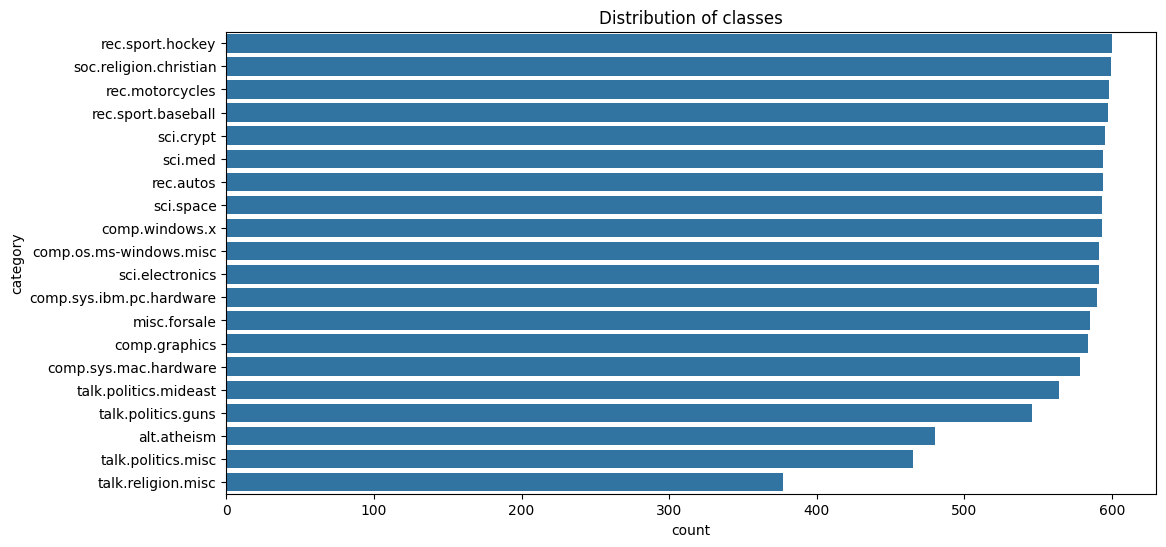

In [11]:
# Is the dataset balanced? -> Class distribution

plt.figure(figsize=(12,6))
sns.countplot(data=df, y="category", order=df["category"].value_counts().index)

plt.title("Distribution of classes")
plt.show()

The dataset seems quite balanced, with the exception with 3 topics which have a bit smaller number of occurrences (but still, comparable to the others).

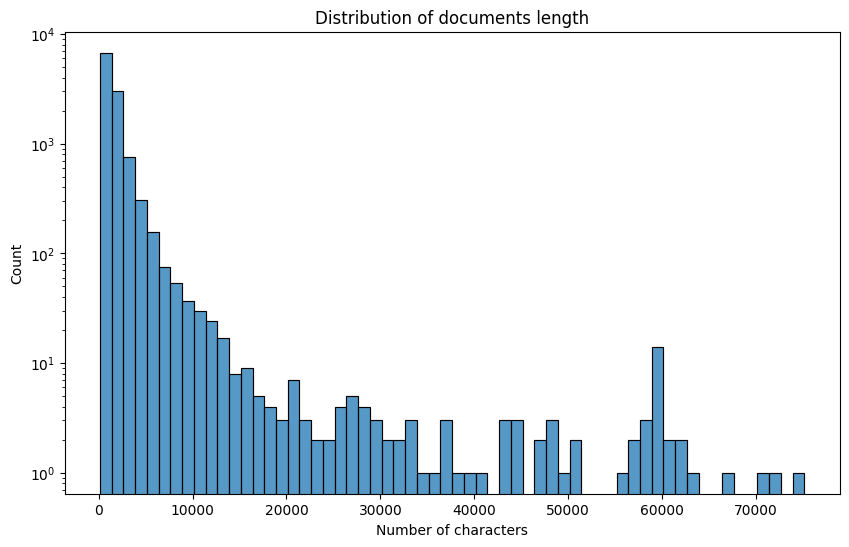

In [16]:
# Documents length (characters)

df["text_length"] = df["text"].apply(len)

plt.figure(figsize=(10,6))
sns.histplot(df["text_length"], bins=60)

plt.title("Distribution of documents length")
plt.xlabel("Number of characters")
plt.yscale("log")
plt.show()

category
misc.forsale                1040.830769
comp.sys.mac.hardware       1200.714533
rec.motorcycles             1352.433110
comp.sys.ibm.pc.hardware    1352.688136
sci.electronics             1374.798646
rec.sport.baseball          1421.041876
rec.autos                   1444.897306
comp.graphics               1557.083904
rec.sport.hockey            1978.746667
sci.med                     2008.121212
sci.space                   2016.170320
comp.windows.x              2092.905565
alt.atheism                 2167.302083
talk.religion.misc          2212.915119
soc.religion.christian      2263.183639
talk.politics.guns          2400.789377
sci.crypt                   2521.156303
talk.politics.misc          2852.027957
comp.os.ms-windows.misc     2992.588832
talk.politics.mideast       3126.902482
Name: text_length, dtype: float64


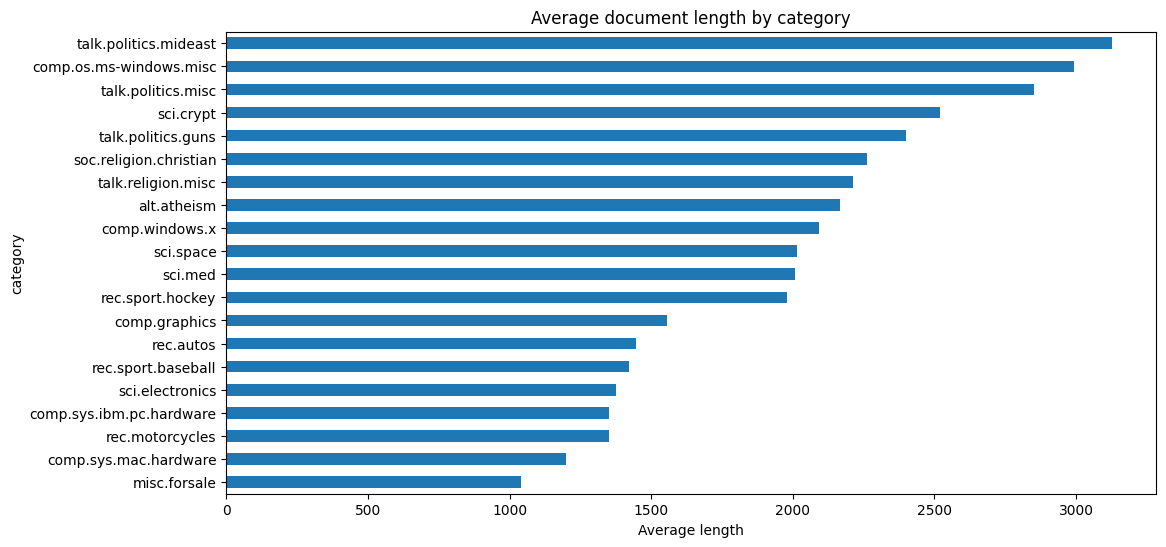

In [17]:
# Average length (characters) per category

avg_len = df.groupby("category")["text_length"].mean().sort_values()
print(avg_len)

plt.figure(figsize=(12,6))
avg_len.plot(kind="barh")

plt.title("Average document length by category")
plt.xlabel("Average length")
plt.show()

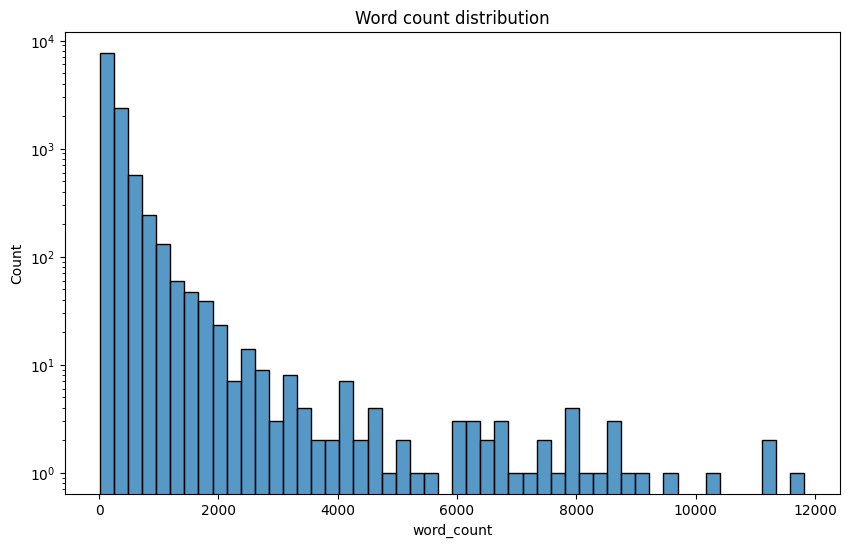

In [19]:
# Number of words per document

df["word_count"] = df["text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(10,6))
sns.histplot(df["word_count"], bins=50)

plt.title("Word count distribution")
plt.yscale("log")
plt.show()

## 2. Text pre-processing

In [11]:
# Function to clean the text

def clean(text):

    text = text.lower()
    text = re.sub(r'\S+@\S+', ' ', text) # remove emails
    text = re.sub(r'\n', ' ', text) # remove new lines
    text = re.sub(r'[^\w\s]', ' ', text) # remove punctuation
    text = re.sub(r'\d+', ' ', text) # remove numbers
    text = re.sub(r'\s+', ' ', text) # remove extra spaces

    return text

In [13]:
df["clean_text"] = df["text"].apply(clean)

print(f"Before cleaning: {df["text"].iloc[0]}")
print(f"\nAfter cleaning: {df["clean_text"].iloc[0]}")

Before cleaning: I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail.

After cleaning: i was wondering if anyone out there could enlighten me on this car i saw the other day it was a door sports car looked to be from the late s early s it was called a bricklin the doors were really small in addition the front bumper was separate from the rest of the body this is all i know if anyone can tellme a model name engine specs years of production where this car is made history or whatever info you have on this funky looking car please e mail 


In [22]:
# Vectorization with TF-IDF

vectorizer = TfidfVectorizer(
    stop_words="english",  
    min_df=3,  # ignore words appearing less than 3 times
    max_df=0.7,  # ignore words appearing in more than 70% of the documents
    ngram_range=(1,2),
    sublinear_tf=True
)

In [23]:
X = vectorizer.fit_transform(df["clean_text"])
y = df["target"]

In [24]:
# Check

print(len(y))
print(X.shape)

11314
(11314, 55787)


## 3. Train the model

In [31]:
# Test train split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

In [32]:
print(X_train.shape)
print(X_test.shape)

(10182, 55787)
(1132, 55787)


In [33]:
# Multinomial Naive Bayes

model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

## 4. Evaluation

In [34]:
# predictions

y_pred = model.predict(X_test)

In [36]:
# Metrics for evaluation

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: ", accuracy)

print("Classification report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Accuracy:  0.7464664310954063
Classification report:
                          precision    recall  f1-score   support

             alt.atheism       0.88      0.31      0.46        48
           comp.graphics       0.73      0.71      0.72        58
 comp.os.ms-windows.misc       0.76      0.69      0.73        59
comp.sys.ibm.pc.hardware       0.62      0.76      0.69        59
   comp.sys.mac.hardware       0.86      0.74      0.80        58
          comp.windows.x       0.83      0.88      0.85        59
            misc.forsale       0.77      0.69      0.73        59
               rec.autos       0.84      0.80      0.82        59
         rec.motorcycles       0.94      0.85      0.89        60
      rec.sport.baseball       0.91      0.82      0.86        60
        rec.sport.hockey       0.58      0.95      0.72        60
               sci.crypt       0.75      0.82      0.78        60
         sci.electronics       0.79      0.81      0.80        59
                 sci.m

Accuracy is not too bad (75%), but maybe it can be optimized.

Some categories have a very small recall, and this can happen because as some classes are similar the model mistake them.

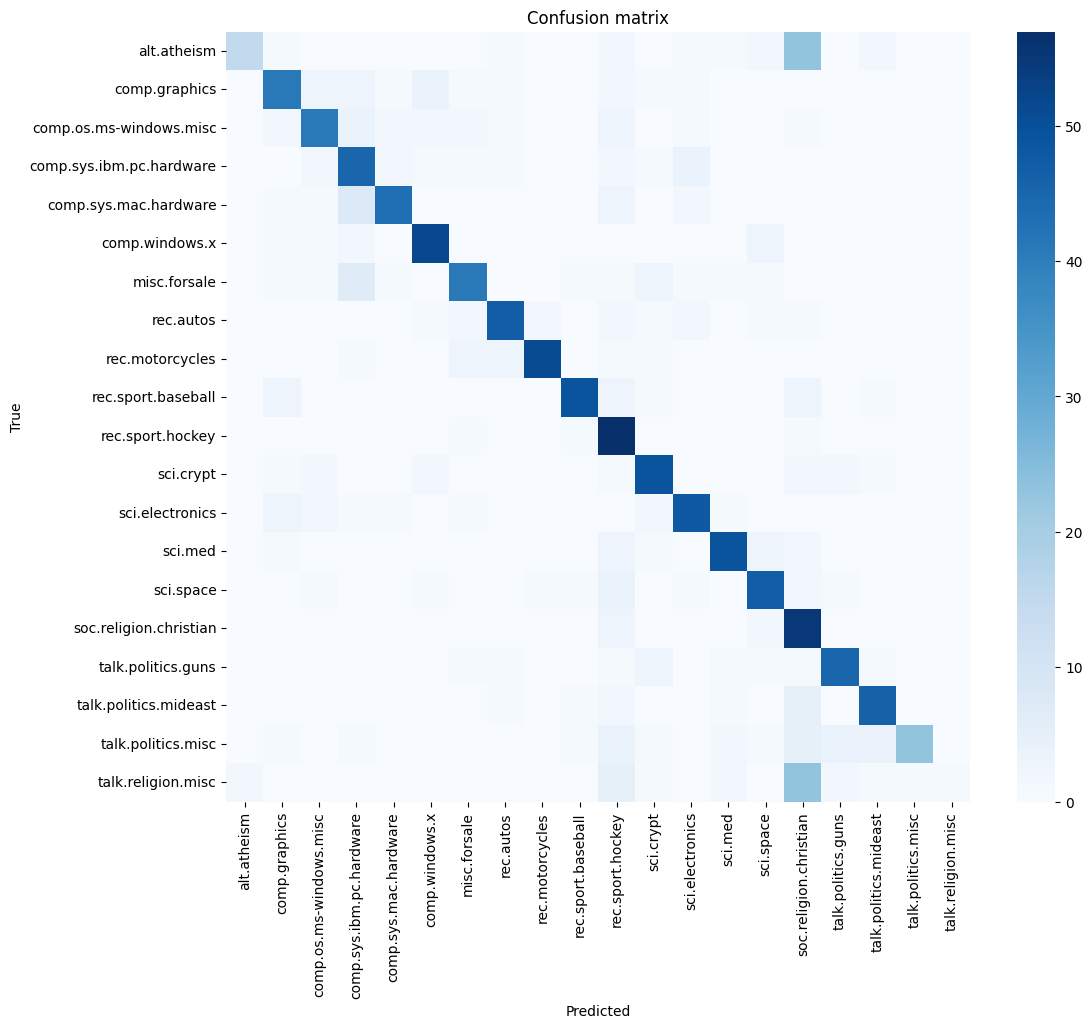

In [37]:
# Confusion matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix")

plt.show()

Sometimes similar classes can be mistaken. The most important cases are soc.religion.christian with talk.religion.misc and soc.religion.christian with alt.atheism. 

## 5. Improve the model

In [40]:
# Search for the best alpha parameter

params = {"alpha": [1.0, 0.5, 0.1, 0.05, 0.01]}

grid = GridSearchCV(
    MultinomialNB(),
    params,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)
print(grid.best_params_)

{'alpha': 0.05}


In [41]:
model = grid.best_estimator_

In [42]:
# Filter more rare words

vectorizer = TfidfVectorizer(
    stop_words="english",  
    min_df=5,
    max_df=0.7,  
    ngram_range=(1,2),
    sublinear_tf=True
)

X = vectorizer.fit_transform(df["clean_text"])

In [43]:
# Train the model

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

model.fit(X_train, y_train)

y_pred_1 = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_1)
print("Accuracy: ", accuracy)

print("Classification report:")
print(classification_report(y_test, y_pred_1, target_names=target_names))

Accuracy:  0.7712014134275619
Classification report:
                          precision    recall  f1-score   support

             alt.atheism       0.77      0.50      0.61        48
           comp.graphics       0.74      0.79      0.77        58
 comp.os.ms-windows.misc       0.78      0.66      0.72        59
comp.sys.ibm.pc.hardware       0.69      0.75      0.72        59
   comp.sys.mac.hardware       0.79      0.79      0.79        58
          comp.windows.x       0.80      0.86      0.83        59
            misc.forsale       0.81      0.73      0.77        59
               rec.autos       0.84      0.80      0.82        59
         rec.motorcycles       0.86      0.80      0.83        60
      rec.sport.baseball       0.87      0.80      0.83        60
        rec.sport.hockey       0.59      0.92      0.71        60
               sci.crypt       0.92      0.75      0.83        60
         sci.electronics       0.75      0.81      0.78        59
                 sci.m

Not only the accuracy improved (from 75% to 77%), but also the recall values that before where very low become higher, meaning that the model tend to become better at recognize ambiguous categories. Also the F1 score increased.

## 6. Which words represent each category?

These are those whose P(word|class) is higher.

In [44]:
feature_names = vectorizer.get_feature_names_out()
model.feature_log_prob_

array([[-11.25717886, -11.25717886, -11.25717886, ..., -11.25717886,
        -11.25717886, -11.25717886],
       [-10.6322829 , -11.33348016, -11.33348016, ..., -11.33348016,
        -11.02135118, -11.33348016],
       [-10.33890626, -11.36918984, -11.36918984, ...,  -9.95532784,
        -11.36918984,  -9.75765502],
       ...,
       [ -9.18499565, -10.03607782, -11.57115906, ..., -11.57115906,
        -11.57115906, -11.57115906],
       [-11.33673952, -11.33673952, -11.33673952, ..., -11.33673952,
        -11.33673952, -11.33673952],
       [-10.55728281, -11.16247811, -11.16247811, ..., -11.16247811,
        -11.16247811, -11.16247811]], shape=(20, 25583))

In [45]:
# Function to find the top words

def top_words_per_class(model, vectorizer, target_names, n=10):

    feature_names = vectorizer.get_feature_names_out()

    for i, category in enumerate(target_names):
        top_indices = np.argsort(model.feature_log_prob_[i])[-n:]
        top_words = [feature_names[j] for j in top_indices]

        print(f"\nCategory: {category}")
        print(", ".join(top_words))

In [46]:
top_words_per_class(model, vectorizer, target_names, n=10)


Category: alt.atheism
does, atheists, atheism, just, religion, say, people, think, don, god

Category: comp.graphics
does, hi, looking, know, program, file, files, image, thanks, graphics

Category: comp.os.ms-windows.misc
drivers, win, using, thanks, use, driver, files, dos, file, windows

Category: comp.sys.ibm.pc.hardware
dx, mb, pc, ide, thanks, scsi, bus, controller, drive, card

Category: comp.sys.mac.hardware
quadra, lc, use, know, problem, does, thanks, drive, apple, mac

Category: comp.windows.x
code, sun, using, application, use, widget, thanks, server, motif, window

Category: misc.forsale
asking, price, interested, email, sell, new, condition, shipping, offer, sale

Category: rec.autos
don, dealer, good, ford, new, just, engine, like, cars, car

Category: rec.motorcycles
know, helmet, motorcycle, just, riding, like, ride, bikes, dod, bike

Category: rec.sport.baseball
pitching, runs, players, braves, hit, games, game, team, baseball, year

Category: rec.sport.hockey
teams,